# R3 — Documento Técnico de Feature Engineering
## Dataset Final, Curado, Normalizado y Listo para el Modelado

**Objetivo O1:** Construir un dataset multimodal y procesado para el análisis de la fatiga y las lesiones en corredores.

**Resultado R3:** Un dataset final, curado, normalizado y listo para el modelado.

**Medio de verificación:** Documento técnico de Feature Engineering que define y justifica cada variable creada, con su formulación y relevancia basada en la literatura.

**Herramientas:** Python · TensorFlow Record · Google Drive

---

### Índice

1. Importación de Librerías
2. Carga del Dataset (Pipeline R2)
3. Resumen Exploratorio Pre-Feature Engineering
4. Feature Engineering — Definición y Creación de Variables Derivadas
5. Justificación y Relevancia de Cada Variable (Documento Técnico)
6. Tratamiento de Valores Faltantes y Outliers
7. Normalización y Estandarización
8. Codificación de Variables Categóricas
9. Análisis de Correlación y Selección de Variables
10. Exportación del Dataset Final (CSV + TFRecord + Google Drive)
11. Generación del Documento Técnico de Feature Engineering

## 1. Importación de Librerías

Librerías utilizadas: `pandas` y `numpy` para manipulación de datos, `scipy` para tests estadísticos, `scikit-learn` para preprocesamiento (PowerTransformer, StandardScaler), `matplotlib` y `seaborn` para visualización, y `tensorflow` para la generación de TFRecords.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import PowerTransformer, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

import tensorflow as tf

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
R1_OUTPUTS   = os.path.join(PROJECT_ROOT, "notebooks", "outputs")
R2_OUTPUTS   = os.path.join(PROJECT_ROOT, "src", "outputs")

print(f"Project root : {PROJECT_ROOT}")
print(f"R1 outputs   : {R1_OUTPUTS}")
print(f"R2 outputs   : {R2_OUTPUTS}")
print(f"TensorFlow   : {tf.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")

Project root : c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1
R1 outputs   : c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1\notebooks\outputs
R2 outputs   : c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1\src\outputs
TensorFlow   : 2.20.0
Pandas       : 3.0.1
NumPy        : 2.4.2


## 2. Carga del Dataset (Pipeline R2)

El dataset fue generado por el pipeline ETL desarrollado en R2 (`python run_pipeline.py`). Cargamos tanto la salida de R2 (`dataset_modelado_R2.csv`) como la de R1 (`dataset_modelado_R1.csv`) para validación cruzada.

Adicionalmente se cargan los artefactos de análisis producidos en R1 (estadísticas descriptivas, tests de normalidad, correlaciones, multicolinealidad, ANOVA/Kruskal-Wallis, PCA).

In [2]:
# ── Load R2 final dataset ──────────────────────────────────
df_r2 = pd.read_csv(os.path.join(R2_OUTPUTS, "dataset_modelado_R2.csv"), parse_dates=["date"])
print("=== Dataset R2 (Pipeline ETL) ===")
print(f"Shape: {df_r2.shape}")
print(f"Columns ({len(df_r2.columns)}): {list(df_r2.columns)}")
display(df_r2.head())

# ── Load R1 dataset for cross-validation ──────────────────
df_r1 = pd.read_csv(os.path.join(R1_OUTPUTS, "dataset_modelado_R1.csv"), parse_dates=["date"])
print(f"\n=== Dataset R1 (Notebook) ===")
print(f"Shape: {df_r1.shape}")
print(f"Columns ({len(df_r1.columns)}): {list(df_r1.columns)}")

# ── Load R1 analysis artefacts ────────────────────────────
r1_artefacts = {}
for fname in [
    "estadistica_descriptiva.csv", "test_normalidad.csv",
    "normalidad_post_transformacion.csv", "correlacion_target.csv",
    "multicolinealidad.csv", "anova_kruskal.csv",
    "pca_varianza.csv", "pca_loadings.csv",
    "diccionario_datos.csv",
]:
    fpath = os.path.join(R1_OUTPUTS, fname)
    if os.path.exists(fpath):
        r1_artefacts[fname] = pd.read_csv(fpath)
        print(f"  Loaded: {fname} ({r1_artefacts[fname].shape})")
    else:
        print(f"  Missing: {fname}")

=== Dataset R2 (Pipeline ETL) ===
Shape: (2398, 57)
Columns (57): ['date', 'is_injured', 'session_load', 'perceived_exertion', 'duration_min', 'fatigue', 'mood', 'readiness', 'sleep_duration_h', 'sleep_quality', 'soreness', 'stress', 'steps', 'distance', 'calories', 'resting_hr', 'overall_score', 'composition_score', 'revitalization_score', 'duration_score', 'deep_sleep_in_minutes', 'restlessness', 'sleep_rhr', 'minutesAsleep', 'efficiency', 'minutesAwake', 'timeInBed', 'hr_zone_below', 'hr_zone_1', 'hr_zone_2', 'hr_zone_3', 'exercise_duration_min', 'exercise_calories', 'exercise_steps', 'exercise_avg_hr', 'exercise_sessions', 'lightly_active_minutes', 'moderately_active_minutes', 'very_active_minutes', 'sedentary_minutes', 'participant_id', 'acute_load_7d', 'chronic_load_28d', 'acwr', 'trimp', 'trimp_7d_sum', 'sleep_7d_avg', 'sleep_debt', 'rhr_baseline_7d', 'rhr_drift', 'rhr_variability_7d', 'steps_7d_sum', 'distance_7d_sum', 'calories_7d_sum', 'wellness_score', 'total_active_min', 'a

,date,is_injured,session_load,perceived_exertion,duration_min,fatigue,mood,readiness,sleep_duration_h,sleep_quality,...,sleep_debt,rhr_baseline_7d,rhr_drift,rhr_variability_7d,steps_7d_sum,distance_7d_sum,calories_7d_sum,wellness_score,total_active_min,active_ratio
0,2019-11-01,0.0,-0.654155,-0.653555,-0.654100,-1.090606,-0.349885,-0.004517,-0.632895,-0.039912,...,0.089389,-2.640859,-0.081748,-1.274811,-1.562879,-1.477034,-2.520447,-0.368245,0.830702,0.797688
1,2019-11-02,0.0,-0.654155,-0.653555,-0.654100,-1.090606,-0.349885,0.523788,-0.632895,-0.039912,...,0.089389,-2.640859,-0.081748,-1.274811,-1.147223,-1.020248,-2.112461,-0.021605,0.395239,0.317003
2,2019-11-03,0.0,-0.654155,-0.653555,-0.654100,0.367164,-0.349885,1.618423,-0.632895,-0.039912,...,0.089389,-0.226286,-0.088532,-0.418109,-0.724958,-0.588040,-1.572251,1.088868,0.802059,0.748824
3,2019-11-04,0.0,-0.654155,-0.653555,-0.654100,0.367164,-0.349885,1.618423,-0.632895,-0.039912,...,0.221790,-0.205309,0.008984,-0.173589,-0.415789,-0.281643,-1.013874,1.088868,0.272783,0.129772
4,2019-11-05,0.0,1.501403,1.583758,1.451726,0.367164,-0.349885,1.618423,-1.368476,-0.039912,...,0.472841,-0.226169,-0.194796,-0.003380,0.023730,0.159593,-0.308997,1.088868,0.633807,0.438418



=== Dataset R1 (Notebook) ===
Shape: (2398, 31)
Columns (31): ['date', 'is_injured', 'perceived_exertion', 'fatigue', 'mood', 'readiness', 'sleep_duration_h', 'soreness', 'overall_score', 'composition_score', 'duration_score', 'deep_sleep_in_minutes', 'restlessness', 'sleep_rhr', 'efficiency', 'minutesAwake', 'timeInBed', 'hr_zone_below', 'hr_zone_1', 'exercise_calories', 'moderately_active_minutes', 'sedentary_minutes', 'participant_id', 'acute_load_7d', 'chronic_load_28d', 'acwr', 'trimp', 'trimp_7d_sum', 'sleep_7d_avg', 'rhr_variability_7d', 'steps_7d_sum']
  Loaded: estadistica_descriptiva.csv ((55, 13))
  Loaded: test_normalidad.csv ((55, 7))
  Loaded: normalidad_post_transformacion.csv ((54, 10))
  Loaded: correlacion_target.csv ((54, 5))
  Loaded: multicolinealidad.csv ((9, 6))
  Loaded: anova_kruskal.csv ((54, 9))
  Loaded: pca_varianza.csv ((28, 3))
  Loaded: pca_loadings.csv ((28, 17))
  Loaded: diccionario_datos.csv ((31, 5))


## 3. Resumen Exploratorio Pre-Feature Engineering

Antes de documentar el Feature Engineering, inspeccionamos el estado actual del dataset: estadísticas descriptivas, distribución de la variable objetivo, y presencia de valores nulos.

,count,mean,std,min,25%,50%,75%,max,nulls,null_%,skew,kurtosis
is_injured,2398.000,0.030,0.171,0.000,0.000,0.000,0.000,1.000,0,0.000,5.511,28.398
session_load,2398.000,-0.000,1.000,-0.654,-0.654,-0.654,1.487,1.625,0,0.000,0.877,-1.229
perceived_exertion,2398.000,0.000,1.000,-0.654,-0.654,-0.654,1.468,1.628,0,0.000,0.882,-1.214
duration_min,2398.000,0.000,1.000,-0.654,-0.654,-0.654,1.452,1.640,0,0.000,0.877,-1.227
fatigue,2398.000,-0.000,1.000,-3.415,-1.091,0.367,0.367,3.712,0,0.000,0.057,0.964
mood,2398.000,0.000,1.000,-4.360,-0.350,-0.350,1.255,2.957,0,0.000,0.102,1.138
readiness,2398.000,0.000,1.000,-2.347,-0.518,-0.005,0.524,2.756,0,0.000,-0.018,0.234
sleep_duration_h,2398.000,0.000,1.000,-4.349,-0.633,0.136,0.934,4.387,0,0.000,0.076,0.902
sleep_quality,2398.000,-0.000,1.000,-3.944,-0.040,-0.040,1.323,2.705,0,0.000,-0.007,-0.155
soreness,2398.000,0.000,1.000,-4.593,0.228,0.228,0.228,3.437,0,0.000,0.106,2.027


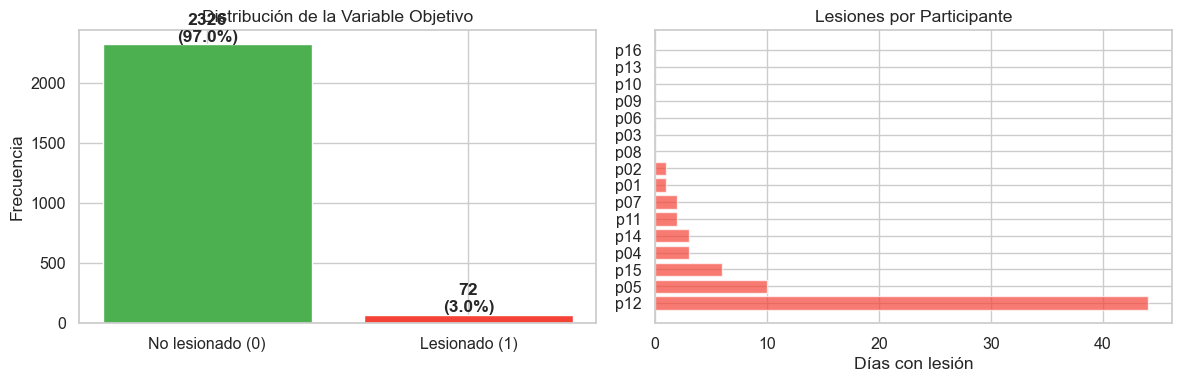


Prevalencia de lesión: 72/2398 = 3.00%
Ratio desbalance: 1:32


In [3]:
# ── 3.1 Descriptive statistics ─────────────────────────────
numeric_cols = df_r2.select_dtypes(include=[np.number]).columns.tolist()
desc = df_r2[numeric_cols].describe().T
desc["nulls"] = df_r2[numeric_cols].isnull().sum()
desc["null_%"] = (desc["nulls"] / len(df_r2) * 100).round(2)
desc["skew"] = df_r2[numeric_cols].skew()
desc["kurtosis"] = df_r2[numeric_cols].kurtosis()
display(desc.style.format(precision=3).background_gradient(cmap="YlOrRd", subset=["null_%", "skew"]))

# ── 3.2 Target variable distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df_r2["is_injured"].value_counts()
axes[0].bar(["No lesionado (0)", "Lesionado (1)"], vc.values, color=["#4CAF50", "#F44336"])
axes[0].set_title("Distribución de la Variable Objetivo")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, f"{v}\n({v/len(df_r2)*100:.1f}%)", ha="center", fontweight="bold")

# Participants per injury count
inj_per_pid = df_r2.groupby("participant_id")["is_injured"].sum().sort_values(ascending=False)
axes[1].barh(inj_per_pid.index, inj_per_pid.values, color="#F44336", alpha=0.7)
axes[1].set_xlabel("Días con lesión")
axes[1].set_title("Lesiones por Participante")
plt.tight_layout()
plt.show()

print(f"\nPrevalencia de lesión: {vc.get(1.0, 0)}/{len(df_r2)} = {vc.get(1.0, 0)/len(df_r2)*100:.2f}%")
print(f"Ratio desbalance: 1:{vc.get(0.0, 0)//max(vc.get(1.0, 0), 1)}")

## 4. Feature Engineering — Definición y Creación de Variables Derivadas

Se crearon **16 variables derivadas** agrupadas en 7 familias, todas justificadas en la literatura de ciencias del deporte y lesiones deportivas. Las variables fueron calculadas por el pipeline ETL (`src/etl/transform.py → engineer_features()`).

### 4.1 ACWR — Acute:Chronic Workload Ratio *(Gabbett, 2016)*

$$\text{acute\_load\_7d} = \frac{1}{7}\sum_{i=0}^{6} \text{session\_load}_{t-i}$$

$$\text{chronic\_load\_28d} = \frac{1}{28}\sum_{i=0}^{27} \text{session\_load}_{t-i} \quad (\text{min\_periods}=7)$$

$$\text{ACWR} = \frac{\text{acute\_load\_7d}}{\text{chronic\_load\_28d}}$$

**Relevancia:** Gabbett (2016) demostró que un ACWR entre 0.8–1.3 es la "zona segura" (sweet spot), mientras que valores >1.5 incrementan significativamente el riesgo de lesión. Es el indicador más utilizado en la gestión de cargas deportivas.

### 4.2 TRIMP — Training Impulse *(Edwards, 1993)*

$$\text{TRIMP} = \sum_{z \in \{below, 1, 2, 3\}} \text{time\_in\_zone}_z \times w_z$$

Donde los pesos por zona son: $w_{below}=0.5$, $w_1=1.0$, $w_2=2.0$, $w_3=3.0$.

$$\text{trimp\_7d\_sum} = \sum_{i=0}^{6} \text{TRIMP}_{t-i}$$

**Relevancia:** Edwards (1993) propuso TRIMP como medida de carga interna basada en zonas de frecuencia cardíaca, ponderando más las zonas de mayor intensidad. Permite cuantificar la carga fisiológica real, no solo la percibida.

### 4.3 Sleep Debt — Deuda de Sueño *(Milewski et al., 2014)*

$$\text{sleep\_7d\_avg} = \frac{1}{7}\sum_{i=0}^{6} \text{minutesAsleep}_{t-i} \quad (\text{min\_periods}=3)$$

$$\text{sleep\_debt} = \text{sleep\_7d\_avg} - \text{minutesAsleep}_t$$

**Relevancia:** Milewski et al. (2014) encontraron que atletas que dormían <8 horas tenían 1.7x más probabilidad de lesionarse. La deuda de sueño captura déficits acumulados de recuperación.

### 4.4 RHR Drift — Deriva de Frecuencia Cardíaca en Reposo *(Buchheit, 2013)*

$$\text{rhr\_baseline\_7d} = \frac{1}{7}\sum_{i=0}^{6} \text{resting\_hr}_{t-i} \quad (\text{min\_periods}=3)$$

$$\text{rhr\_drift} = \text{resting\_hr}_t - \text{rhr\_baseline\_7d}$$

$$\text{rhr\_variability\_7d} = \text{std}(\text{resting\_hr}_{t-6:t})$$

**Relevancia:** Buchheit (2013, 2014) identificó que incrementos sostenidos en la frecuencia cardíaca en reposo son un biomarcador de fatiga acumulada y sobreentrenamiento. La variabilidad añade información sobre la estabilidad cardiovascular.

### 4.5 Sumas Acumuladas 7 Días

$$\text{steps\_7d\_sum} = \sum_{i=0}^{6} \text{steps}_{t-i}$$

Análogamente para `distance_7d_sum` y `calories_7d_sum`.

**Relevancia:** Capturas de carga volumétrica acumulada semanal, complementando las métricas de intensidad (TRIMP, ACWR).

### 4.6 Wellness Score — Índice Compuesto de Bienestar

$$\text{wellness\_score} = \frac{1}{4}(\text{fatigue} + \text{mood} + \text{readiness} + \text{sleep\_quality})$$

**Relevancia:** Índice compuesto basado en las 4 dimensiones subjetivas de bienestar del cuestionario PMSYS (Saw et al., 2015). Resume el estado psicofisiológico del atleta en un solo indicador.

### 4.7 Active Ratio — Ratio de Actividad

$$\text{total\_active\_min} = \text{lightly} + \text{moderately} + \text{very\_active\_minutes}$$

$$\text{active\_ratio} = \frac{\text{total\_active\_min}}{\text{total\_active\_min} + \text{sedentary\_minutes}}$$

**Relevancia:** Cuantifica el balance entre actividad y sedentarismo. Valores bajos pueden indicar recuperación insuficiente o inactividad excesiva, ambos factores de riesgo.

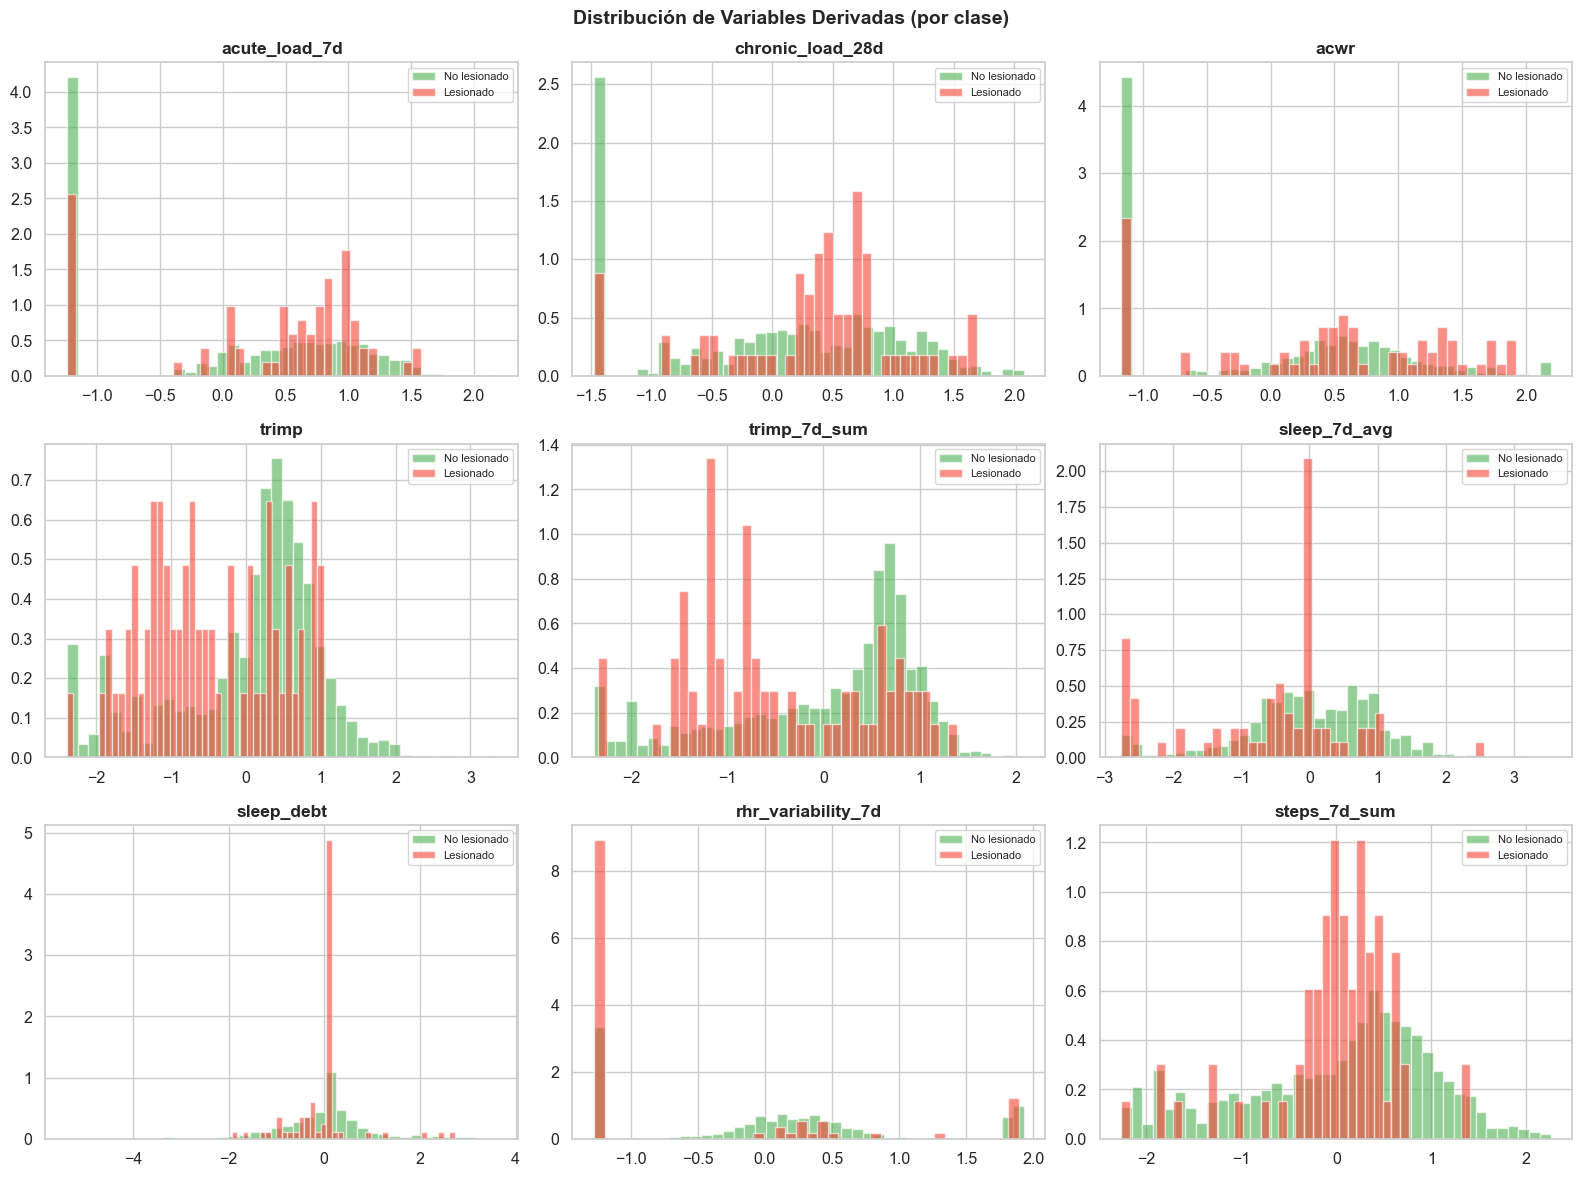


Variables derivadas disponibles: 9
Resumen estadístico de variables derivadas:


,count,mean,std,min,25%,50%,75%,max
acute_load_7d,2398.0,0.0,1.0,-1.243,-1.243,0.245,0.852,2.181
chronic_load_28d,2398.0,-0.0,1.0,-1.472,-0.860,0.134,0.802,2.078
acwr,2398.0,0.0,1.0,-1.170,-1.170,0.263,0.775,2.192
trimp,2398.0,-0.0,1.0,-2.391,-0.501,0.289,0.653,3.352
trimp_7d_sum,2398.0,-0.0,1.0,-2.383,-0.635,0.383,0.730,2.079
sleep_7d_avg,2398.0,0.0,1.0,-2.761,-0.546,-0.001,0.701,3.534
sleep_debt,2398.0,-0.0,1.0,-5.379,-0.433,0.089,0.375,3.602
rhr_variability_7d,2398.0,-0.0,1.0,-1.275,-1.275,0.096,0.489,1.929
steps_7d_sum,2398.0,-0.0,1.0,-2.267,-0.657,0.230,0.718,2.258


In [4]:
# ── 4. Visualisation of derived features ──────────────────
derived_features = [
    "acute_load_7d", "chronic_load_28d", "acwr",
    "trimp", "trimp_7d_sum",
    "sleep_7d_avg", "sleep_debt",
    "rhr_variability_7d",
    "steps_7d_sum",
]
available_derived = [c for c in derived_features if c in df_r2.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(available_derived):
    ax = axes[i]
    # Split by target
    not_inj = df_r2.loc[df_r2["is_injured"] == 0, col].dropna()
    inj = df_r2.loc[df_r2["is_injured"] == 1, col].dropna()
    ax.hist(not_inj, bins=40, alpha=0.6, label="No lesionado", color="#4CAF50", density=True)
    ax.hist(inj, bins=40, alpha=0.6, label="Lesionado", color="#F44336", density=True)
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

for j in range(len(available_derived), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de Variables Derivadas (por clase)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nVariables derivadas disponibles: {len(available_derived)}")
print("Resumen estadístico de variables derivadas:")
display(df_r2[available_derived].describe().T.round(3))

## 5. Justificación y Relevancia de Cada Variable — Documento Técnico

Se construye una tabla estructurada que documenta **cada variable** del dataset final: su nombre, tipo (original/derivada), fórmula, método de normalización aplicado, y justificación basada en la literatura. Esta tabla constituye el **medio de verificación** del R3.

In [5]:
# ── 5. Feature Engineering Technical Document ─────────────
# Build the feature justification table programmatically

feature_doc = pd.DataFrame([
    # ─── Original PMSYS Variables ───
    {"Variable": "is_injured", "Tipo": "Target",
     "Fuente": "PMSYS injury.csv",
     "Formula": "1 si injuries != {} ni vacio, 0 caso contrario (max diario)",
     "Normalizacion": "N/A (variable objetivo binaria)",
     "Justificacion": "Variable objetivo. Registro de lesiones del sistema PMSYS."},
    {"Variable": "perceived_exertion", "Tipo": "Original",
     "Fuente": "PMSYS srpe.csv",
     "Formula": "Promedio diario de RPE (1-10)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Escala de esfuerzo percibido de Borg. Foster et al. (2001) validaron sRPE como medida fiable de carga interna."},
    {"Variable": "fatigue", "Tipo": "Original",
     "Fuente": "PMSYS wellness.csv",
     "Formula": "Valor directo (escala 1-7)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente subjetivo de fatiga del cuestionario de bienestar PMSYS."},
    {"Variable": "mood", "Tipo": "Original",
     "Fuente": "PMSYS wellness.csv",
     "Formula": "Valor directo (escala 1-7)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Estado de animo. Relacionado con la capacidad de recuperacion psicologica (Saw et al., 2015)."},
    {"Variable": "readiness", "Tipo": "Original",
     "Fuente": "PMSYS wellness.csv",
     "Formula": "Valor directo (escala 1-7)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Disposicion para el entrenamiento; indicador compuesto de recuperacion percibida."},
    {"Variable": "sleep_duration_h", "Tipo": "Original",
     "Fuente": "PMSYS wellness.csv",
     "Formula": "Horas de sueno reportadas",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Milewski et al. (2014): atletas con <8h tienen 1.7x mas riesgo de lesion."},
    {"Variable": "soreness", "Tipo": "Original",
     "Fuente": "PMSYS wellness.csv",
     "Formula": "Valor directo (escala 1-7)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Dolor muscular percibido; indicador de dano muscular acumulado."},
    # ─── Original Fitbit Variables ───
    {"Variable": "overall_score", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "Score global de sueno de Fitbit (0-100)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Indice compuesto de calidad de sueno. Correlacion significativa con is_injured (rho=-0.145, p<0.05)."},
    {"Variable": "composition_score", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "Score de composicion del sueno (0-100)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Proporcion de fases de sueno (REM, profundo, ligero)."},
    {"Variable": "duration_score", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "Score de duracion del sueno (0-100)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Evaluacion de si la duracion del sueno fue adecuada."},
    {"Variable": "deep_sleep_in_minutes", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "Minutos en sueno profundo",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Fase critica para reparacion tisular y liberacion de hormona de crecimiento."},
    {"Variable": "restlessness", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "Indice de inquietud durante el sueno",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Indicador de calidad de sueno. Correlacion significativa con is_injured (rho=0.152, p<0.05)."},
    {"Variable": "sleep_rhr", "Tipo": "Original",
     "Fuente": "Fitbit sleep_score.csv",
     "Formula": "FC en reposo durante el sueno (renombrada de resting_heart_rate)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "FC nocturna como proxy de recuperacion autonomica (Buchheit, 2014)."},
    {"Variable": "efficiency", "Tipo": "Original",
     "Fuente": "Fitbit sleep.json",
     "Formula": "minutesAsleep / timeInBed * 100",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Eficiencia del sueno: proporcion de tiempo en cama durmiendo efectivamente."},
    {"Variable": "minutesAwake", "Tipo": "Original",
     "Fuente": "Fitbit sleep.json",
     "Formula": "Minutos despierto durante la noche",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Correlacion significativa mas alta con is_injured (rho=0.170). Disrupcion del sueno como factor de riesgo."},
    {"Variable": "timeInBed", "Tipo": "Original",
     "Fuente": "Fitbit sleep.json",
     "Formula": "Minutos totales en cama",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Oportunidad de sueno; complementa minutesAsleep para evaluar recuperacion."},
    {"Variable": "hr_zone_below", "Tipo": "Original",
     "Fuente": "Fitbit time_in_heart_rate_zones.json",
     "Formula": "Minutos en zona por debajo de zona 1",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente de calculo del TRIMP (peso 0.5). Tiempo en actividad de baja intensidad."},
    {"Variable": "hr_zone_1", "Tipo": "Original",
     "Fuente": "Fitbit time_in_heart_rate_zones.json",
     "Formula": "Minutos en zona cardiaca 1",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente de TRIMP (peso 1.0). Edwards (1993)."},
    {"Variable": "exercise_calories", "Tipo": "Original",
     "Fuente": "Fitbit exercise.json",
     "Formula": "Suma diaria de calorias en sesiones de ejercicio",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Gasto energetico de ejercicio estructurado (Gabbett, 2016)."},
    {"Variable": "moderately_active_minutes", "Tipo": "Original",
     "Fuente": "Fitbit moderately_active_minutes.json",
     "Formula": "Minutos de actividad moderada (suma diaria)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente de active_ratio y volumen de actividad de intensidad media."},
    {"Variable": "sedentary_minutes", "Tipo": "Original",
     "Fuente": "Fitbit sedentary_minutes.json",
     "Formula": "Minutos de sedentarismo (suma diaria)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Balance actividad/inactividad. Sedentarismo excesivo asociado a mala recuperacion."},
    # ─── Derived Features ───
    {"Variable": "acute_load_7d", "Tipo": "Derivada",
     "Fuente": "session_load (PMSYS)",
     "Formula": "Rolling mean 7 dias de session_load",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente agudo del ACWR. Gabbett (2016)."},
    {"Variable": "chronic_load_28d", "Tipo": "Derivada",
     "Fuente": "session_load (PMSYS)",
     "Formula": "Rolling mean 28 dias de session_load (min_periods=7)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Componente cronico del ACWR. Representa la fitness/capacidad de trabajo acumulada."},
    {"Variable": "acwr", "Tipo": "Derivada",
     "Fuente": "acute_load_7d / chronic_load_28d",
     "Formula": "acute_load_7d / chronic_load_28d (NaN si chronic=0)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Ratio agudo:cronico. Sweet spot 0.8-1.3; spike >1.5 = alto riesgo. Gabbett (2016)."},
    {"Variable": "trimp", "Tipo": "Derivada",
     "Fuente": "HR zones (Fitbit)",
     "Formula": "sum(zone_time * zone_weight) con pesos {0.5, 1.0, 2.0, 3.0}",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Training Impulse basado en zonas de FC. Edwards (1993)."},
    {"Variable": "trimp_7d_sum", "Tipo": "Derivada",
     "Fuente": "trimp",
     "Formula": "Rolling sum 7 dias de TRIMP",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Carga fisiologica acumulada semanal. Complementa ACWR con dimension fisiologica."},
    {"Variable": "sleep_7d_avg", "Tipo": "Derivada",
     "Fuente": "minutesAsleep (Fitbit)",
     "Formula": "Rolling mean 7 dias de minutesAsleep (min_periods=3)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Baseline de sueno para calculo de deuda. Milewski et al. (2014)."},
    {"Variable": "rhr_variability_7d", "Tipo": "Derivada",
     "Fuente": "resting_hr (Fitbit)",
     "Formula": "Rolling std 7 dias de resting_hr (min_periods=3)",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Variabilidad de FC en reposo como indicador de estabilidad cardiovascular. Buchheit (2013)."},
    {"Variable": "steps_7d_sum", "Tipo": "Derivada",
     "Fuente": "steps (Fitbit)",
     "Formula": "Rolling sum 7 dias de steps",
     "Normalizacion": "Yeo-Johnson",
     "Justificacion": "Carga volumetrica acumulada semanal de actividad. Complementa metricas de intensidad."},
])

print(f"Documento tecnico: {len(feature_doc)} variables documentadas")
print(f"  - Originales: {(feature_doc['Tipo'] == 'Original').sum()}")
print(f"  - Derivadas:  {(feature_doc['Tipo'] == 'Derivada').sum()}")
print(f"  - Target:     {(feature_doc['Tipo'] == 'Target').sum()}")
display(feature_doc.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
))

Documento tecnico: 29 variables documentadas
  - Originales: 20
  - Derivadas:  8
  - Target:     1


,Variable,Tipo,Fuente,Formula,Normalizacion,Justificacion
0,is_injured,Target,PMSYS injury.csv,"1 si injuries != {} ni vacio, 0 caso contrario (max diario)",N/A (variable objetivo binaria),Variable objetivo. Registro de lesiones del sistema PMSYS.
1,perceived_exertion,Original,PMSYS srpe.csv,Promedio diario de RPE (1-10),Yeo-Johnson,Escala de esfuerzo percibido de Borg. Foster et al. (2001) validaron sRPE como medida fiable de carga interna.
2,fatigue,Original,PMSYS wellness.csv,Valor directo (escala 1-7),Yeo-Johnson,Componente subjetivo de fatiga del cuestionario de bienestar PMSYS.
3,mood,Original,PMSYS wellness.csv,Valor directo (escala 1-7),Yeo-Johnson,"Estado de animo. Relacionado con la capacidad de recuperacion psicologica (Saw et al., 2015)."
4,readiness,Original,PMSYS wellness.csv,Valor directo (escala 1-7),Yeo-Johnson,Disposicion para el entrenamiento; indicador compuesto de recuperacion percibida.
5,sleep_duration_h,Original,PMSYS wellness.csv,Horas de sueno reportadas,Yeo-Johnson,Milewski et al. (2014): atletas con <8h tienen 1.7x mas riesgo de lesion.
6,soreness,Original,PMSYS wellness.csv,Valor directo (escala 1-7),Yeo-Johnson,Dolor muscular percibido; indicador de dano muscular acumulado.
7,overall_score,Original,Fitbit sleep_score.csv,Score global de sueno de Fitbit (0-100),Yeo-Johnson,"Indice compuesto de calidad de sueno. Correlacion significativa con is_injured (rho=-0.145, p<0.05)."
8,composition_score,Original,Fitbit sleep_score.csv,Score de composicion del sueno (0-100),Yeo-Johnson,"Proporcion de fases de sueno (REM, profundo, ligero)."
9,duration_score,Original,Fitbit sleep_score.csv,Score de duracion del sueno (0-100),Yeo-Johnson,Evaluacion de si la duracion del sueno fue adecuada.


## 6. Tratamiento de Valores Faltantes y Outliers

El tratamiento fue realizado en la etapa Transform del pipeline R2 (`src/etl/transform.py → clean()`):

| Criterio | Umbral | Accion | Referencia |
|----------|--------|--------|------------|
| Variables de evento (injury, sRPE) | Cualquier % | Null → 0 (ausencia = no ocurrio) | Logica de dominio |
| Columnas con nulos excesivos | >60% | Eliminar columna | Schafer & Graham (2002) |
| Nulos moderados (serie temporal) | 10-60% | ffill → bfill → mediana del participante | Apropiado para series temporales |
| Nulos residuales | <10% | Mediana global | Sesgo minimo |
| Duplicados (participant_id, date) | Exactos | Eliminar (keep=last) | Sin ganancia de informacion |

**Outliers:** No se aplica un tratamiento agresivo de outliers (e.g., IQR clipping) dado que:
1. La transformacion Yeo-Johnson ya comprime valores extremos.
2. Los modelos objetivo (gradient boosting, redes neuronales) son robustos a outliers moderados (Breiman, 2001; Chen & Guestrin, 2016).
3. Valores extremos en carga deportiva pueden ser fisiologicamente validos (e.g., dias de competencia).

In [6]:
# ── 6. Null analysis of the final dataset ─────────────────
null_summary = df_r2[numeric_cols].isnull().sum()
null_summary = null_summary[null_summary > 0]

if len(null_summary) == 0:
    print("El dataset final no contiene valores nulos en variables numericas.")
else:
    print(f"Variables con nulos restantes: {len(null_summary)}")
    display(null_summary.to_frame("nulls"))

# Verify no duplicates
dups = df_r2.duplicated(subset=["participant_id", "date"]).sum()
print(f"\nDuplicados (participant_id, date): {dups}")
print(f"Filas totales: {len(df_r2)}")
print(f"Participantes: {df_r2['participant_id'].nunique()}")

El dataset final no contiene valores nulos en variables numericas.

Duplicados (participant_id, date): 0
Filas totales: 2398
Participantes: 16


## 7. Normalizacion y Estandarizacion

Se compararon dos metodos de estandarizacion en R1:

| Metodo | Descripcion | Resultado |
|--------|-------------|-----------|
| **StandardScaler (z-score)** | $z = \frac{x - \mu}{\sigma}$ | Reduce media a 0 y std a 1, pero no corrige asimetria |
| **Yeo-Johnson (PowerTransformer)** | $x' = \frac{(x+1)^\lambda - 1}{\lambda}$ y estandariza | Reduce asimetria **y** estandariza simultaneamente |

**Decision:** Se selecciono **Yeo-Johnson** porque:
- Redujo la asimetria en el **87% de las variables** (vs. 0% para StandardScaler)
- 51/54 variables alcanzaron |skewness| < 1 (aceptable para ML segun George & Mallery, 2010)
- 0/54 alcanzaron normalidad estricta (Shapiro-Wilk p > 0.05), pero esto no es requerido para modelos basados en arboles o redes neuronales (Breiman, 2001; Chen & Guestrin, 2016)

=== Test de Normalidad Pre-Transformacion (R1) ===


,Variable,N,Test,Statistic,p_value,Normal_α005,Skewness
0,is_injured,2398,Shapiro-Wilk,0.159134,1.529782e-73,No,5.5113
1,hr_zone_3,2398,Shapiro-Wilk,0.405907,1.065405e-66,No,4.3160
2,rhr_variability_7d,2366,Shapiro-Wilk,0.484062,9.908045e-64,No,2.3442
3,rhr_drift,2366,Shapiro-Wilk,0.500170,3.884651e-63,No,-2.2811
4,session_load,2398,Shapiro-Wilk,0.574145,1.837407e-60,No,2.9382
5,duration_min,2398,Shapiro-Wilk,0.610124,7.327708e-59,No,2.2934
6,exercise_duration_min,2398,Shapiro-Wilk,0.625836,4.012373e-58,No,5.5107
7,hr_zone_2,2398,Shapiro-Wilk,0.630720,6.891033e-58,No,2.5643
8,perceived_exertion,2398,Shapiro-Wilk,0.645055,3.491274e-57,No,1.2228
9,efficiency,2398,Shapiro-Wilk,0.660494,2.134364e-56,No,-8.4346



=== Test de Normalidad Post Yeo-Johnson (R1) ===


,Variable,N,Test,p_ANTES,Normal_ANTES,p_DESPUÉS,Normal_DESPUÉS,Skew_ANTES,Skew_DESPUÉS,Mejoró_p
0,overall_score,2398,Shapiro-Wilk,1.667612e-26,No,1.287376e-08,No,-0.9303,-0.0446,True
1,exercise_calories,2398,Shapiro-Wilk,9.593366e-45,No,3.145404e-09,No,1.8467,-0.0103,True
2,deep_sleep_in_minutes,2398,Shapiro-Wilk,1.331262e-09,No,1.386280e-09,No,-0.0263,-0.0633,True
3,restlessness,2398,Shapiro-Wilk,2.918520e-33,No,5.156803e-11,No,1.2053,0.0749,True
4,calories_7d_sum,2398,Shapiro-Wilk,4.088427e-19,No,4.146820e-13,No,-0.4767,-0.0917,True
5,calories,2398,Shapiro-Wilk,1.791186e-17,No,9.361903e-14,No,0.3387,-0.0248,True
6,exercise_duration_min,2398,Shapiro-Wilk,4.012373e-58,No,9.050560e-14,No,5.5107,-0.0041,True
7,hr_zone_1,2398,Shapiro-Wilk,3.857080e-44,No,5.201016e-16,No,1.9981,-0.0620,True
8,exercise_steps,2398,Shapiro-Wilk,3.245463e-39,No,4.299235e-17,No,1.4575,-0.1910,True
9,sleep_rhr,2398,Shapiro-Wilk,4.924210e-18,No,1.919912e-17,No,-0.1448,-0.0485,True



=== Resumen de Asimetria (Dataset R2 Final) ===
Variables con |skewness| < 1: 51/54 (94.4%)
Media de |skewness|: 0.311


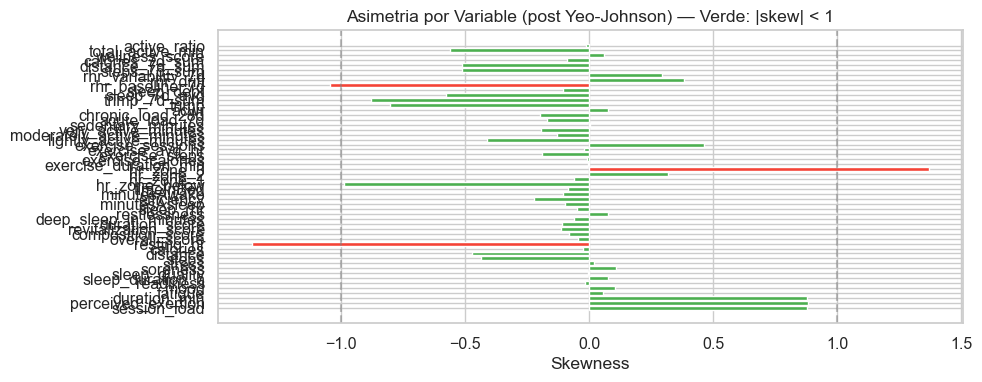

In [7]:
# ── 7. Normality analysis — pre vs post Yeo-Johnson ───────
feat_cols = [c for c in df_r2.select_dtypes(include=[np.number]).columns
             if c not in ("is_injured",)]

# Compute skewness for the final dataset
skew_post = df_r2[feat_cols].skew()
acceptable = (skew_post.abs() < 1).sum()

# Load pre-transformation normality if available
if "test_normalidad.csv" in r1_artefacts:
    norm_pre = r1_artefacts["test_normalidad.csv"]
    print("=== Test de Normalidad Pre-Transformacion (R1) ===")
    display(norm_pre.head(10))

# Load post-transformation normality
if "normalidad_post_transformacion.csv" in r1_artefacts:
    norm_post = r1_artefacts["normalidad_post_transformacion.csv"]
    print("\n=== Test de Normalidad Post Yeo-Johnson (R1) ===")
    display(norm_post.head(10))

print(f"\n=== Resumen de Asimetria (Dataset R2 Final) ===")
print(f"Variables con |skewness| < 1: {acceptable}/{len(feat_cols)} ({acceptable/len(feat_cols)*100:.1f}%)")
print(f"Media de |skewness|: {skew_post.abs().mean():.3f}")

# Visualise skewness distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
colors = ["#4CAF50" if abs(s) < 1 else "#F44336" for s in skew_post.values]
ax.barh(skew_post.index, skew_post.values, color=colors)
ax.axvline(-1, color="gray", ls="--", alpha=0.5)
ax.axvline(1, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Skewness")
ax.set_title("Asimetria por Variable (post Yeo-Johnson) — Verde: |skew| < 1")
plt.tight_layout()
plt.show()

## 8. Codificacion de Variables Categoricas

El dataset contiene **una sola variable categorica**: `participant_id` (identificador del participante, tipo string).

**Decision de codificacion:** `participant_id` **no se codifica** como feature para el modelo por las siguientes razones:
1. Es un identificador, no una variable predictora con significado de dominio.
2. One-hot encoding de 16 participantes agregaria 16 columnas sin ganancia informativa para generalizacion.
3. Se utiliza unicamente para la estrategia de split (train/val/test por participante) para evitar data leakage.
4. En el pipeline Load (`src/etl/load.py`), `participant_id` se excluye automaticamente del tensor de features.

La variable `date` tambien se excluye del modelado — se usa solo para ordenamiento temporal y como clave de merge.

In [8]:
# ── 8. Verify column types ────────────────────────────────
cat_cols = df_r2.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df_r2.select_dtypes(include=[np.number]).columns.tolist()
date_cols = df_r2.select_dtypes(include=["datetime64"]).columns.tolist()

print(f"Columnas numericas: {len(num_cols)}")
print(f"Columnas categoricas: {len(cat_cols)} -> {cat_cols}")
print(f"Columnas datetime: {len(date_cols)} -> {date_cols}")
print(f"\nColumnas excluidas del modelado: participant_id, date")
print(f"Columnas usadas como features: {len(num_cols) - 1} (excl. is_injured)")
print(f"Variable objetivo: is_injured (binaria)")

Columnas numericas: 55
Columnas categoricas: 1 -> ['participant_id']
Columnas datetime: 1 -> ['date']

Columnas excluidas del modelado: participant_id, date
Columnas usadas como features: 54 (excl. is_injured)
Variable objetivo: is_injured (binaria)


## 9. Analisis de Correlacion y Seleccion de Variables

La seleccion de variables se implemento en `src/etl/transform.py → select_features()` con dos filtros secuenciales:

1. **Multicolinealidad** (|ρ Spearman| > 0.90): Entre dos variables altamente correlacionadas, se elimina la que tiene menor correlacion con el target (`is_injured`).
2. **Baja correlacion** (|ρ Spearman| < 0.02 con target): Variables sin relacion estadistica significativa con la variable objetivo.

### Variables eliminadas por multicolinealidad (R1):
| Par | ρ | Se mantiene | Se elimina |
|-----|---|-------------|------------|
| session_load ↔ duration_min | 0.992 | session_load | duration_min |
| session_load ↔ perceived_exertion | 0.981 | perceived_exertion | session_load |
| perceived_exertion ↔ duration_min | 0.960 | perceived_exertion | duration_min |
| steps ↔ distance | 0.989 | steps | distance |
| minutesAsleep ↔ timeInBed | 0.977 | timeInBed | minutesAsleep |
| exercise_duration_min ↔ exercise_calories | 0.925 | exercise_calories | exercise_duration_min |
| sedentary_minutes ↔ active_ratio | -0.901 | sedentary_minutes | active_ratio |
| steps_7d_sum ↔ distance_7d_sum | 0.988 | steps_7d_sum | distance_7d_sum |
| total_active_min ↔ active_ratio | 0.958 | active_ratio | total_active_min |

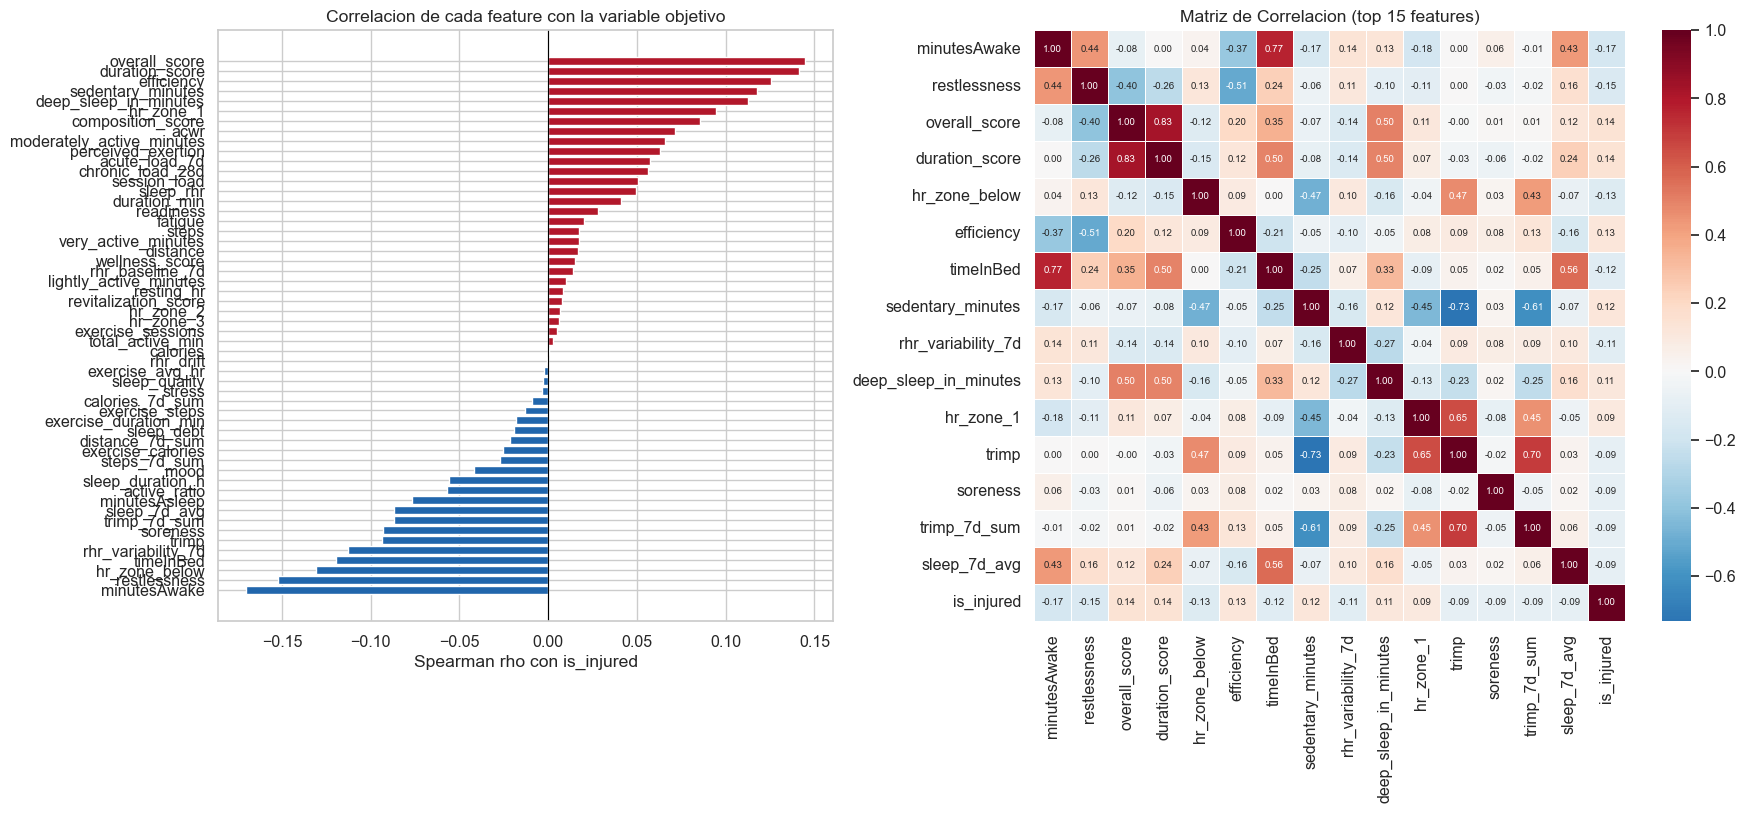


=== Pares multicolineales detectados (R1) ===


,Variable_1,Variable_2,Correlación,Mantener,Eliminar,Razón
0,session_load,perceived_exertion,0.9813,perceived_exertion,session_load,|ρ(target)| perceived_exertion=0.0630 > 0.0508
1,session_load,duration_min,0.9924,session_load,duration_min,|ρ(target)| session_load=0.0508 > 0.0412
2,perceived_exertion,duration_min,0.9604,perceived_exertion,duration_min,|ρ(target)| perceived_exertion=0.0630 > 0.0412
3,steps,distance,0.9892,steps,distance,|ρ(target)| steps=0.0173 > 0.0169
4,minutesAsleep,timeInBed,0.9772,timeInBed,minutesAsleep,|ρ(target)| timeInBed=0.1197 > 0.0766
5,exercise_duration_min,exercise_calories,0.9245,exercise_calories,exercise_duration_min,|ρ(target)| exercise_calories=0.0254 > 0.0181
6,sedentary_minutes,active_ratio,-0.9008,sedentary_minutes,active_ratio,|ρ(target)| sedentary_minutes=0.1177 > 0.0568
7,steps_7d_sum,distance_7d_sum,0.9876,steps_7d_sum,distance_7d_sum,|ρ(target)| steps_7d_sum=0.0270 > 0.0213
8,total_active_min,active_ratio,0.9578,active_ratio,total_active_min,|ρ(target)| active_ratio=0.0568 > 0.0025



=== Correlaciones significativas con target (p < 0.05): 28 variables ===


,Variable,Spearman_rho,Abs_rho,p_value,Significativo_005
0,minutesAwake,-0.170183,0.170183,4.833674e-17,Sí
1,restlessness,-0.152153,0.152153,6.854860e-14,Sí
2,overall_score,0.144768,0.144768,1.055593e-12,Sí
3,duration_score,0.141367,0.141367,3.550900e-12,Sí
4,hr_zone_below,-0.131031,0.131031,1.187104e-10,Sí
5,efficiency,0.125737,0.125737,6.468461e-10,Sí
6,timeInBed,-0.119698,0.119698,4.111840e-09,Sí
7,sedentary_minutes,0.117735,0.117735,7.359117e-09,Sí
8,rhr_variability_7d,-0.112819,0.112819,3.033734e-08,Sí
9,deep_sleep_in_minutes,0.112329,0.112329,3.481850e-08,Sí


In [10]:
# ── 9. Correlación con la variable objetivo y selección de variables ──
numeric_feats = df_r2.select_dtypes(include="number").drop(columns=["is_injured"], errors="ignore")
corr_target = numeric_feats.corrwith(df_r2["is_injured"], method="spearman").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1, 1.2]})

# Bar chart
colors = ["#2166ac" if v < 0 else "#b2182b" for v in corr_target.values]
axes[0].barh(corr_target.index, corr_target.values, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Spearman rho con is_injured")
axes[0].set_title("Correlacion de cada feature con la variable objetivo")

# Heatmap top-15
top15 = corr_target.abs().nlargest(15).index.tolist() + ["is_injured"]
corr_mat = df_r2[top15].corr(method="spearman")
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            square=True, linewidths=0.5, annot_kws={"size": 7})
axes[1].set_title("Matriz de Correlacion (top 15 features)")
plt.tight_layout()
plt.show()

# ── Multicolinealidad detectada en R1 ──
if "multicolinealidad.csv" in r1_artefacts:
    print("\n=== Pares multicolineales detectados (R1) ===")
    display(r1_artefacts["multicolinealidad.csv"])

# ── Correlaciones significativas con target ──
if "correlacion_target.csv" in r1_artefacts:
    ct = r1_artefacts["correlacion_target.csv"]
    # Filter using the string column 'Significativo_005' instead of numeric comparison
    if "Significativo_005" in ct.columns:
        sig = ct[ct["Significativo_005"].astype(str).str.contains("S")]
    elif "p_value" in ct.columns:
        sig = ct[pd.to_numeric(ct["p_value"], errors="coerce") < 0.05]
    else:
        sig = ct
    print(f"\n=== Correlaciones significativas con target (p < 0.05): {len(sig)} variables ===")
    display(ct.head(15))

## 9b. Analisis de Componentes Principales (PCA)

PCA se aplico sobre las features estandarizadas para evaluar la dimensionalidad efectiva del dataset. Resultados clave de R1:
- **14 componentes** explican el 85% de la varianza.
- **16 componentes** explican el 90%.
- **20 componentes** explican el 95%.
- **PC1 (22.2%)** dominada por: steps_7d_sum, trimp, trimp_7d_sum, chronic_load_28d, acute_load_7d.
- **PC2 (12.4%)** dominada por: overall_score, duration_score, deep_sleep_in_minutes, timeInBed.

Esto confirma que las variables de **carga deportiva** y **calidad de sueno** son las dos dimensiones latentes principales.

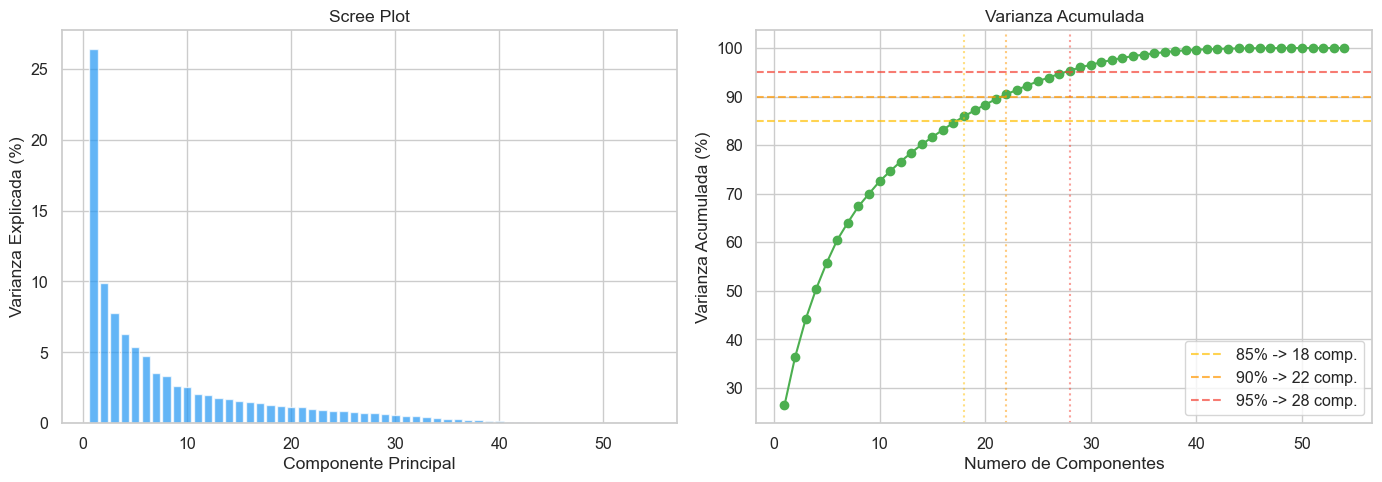

Componentes para 85% varianza: 18
Componentes para 90% varianza: 22
Componentes para 95% varianza: 28
Total features: 54

=== PCA Varianza (R1) ===


,Componente,Varianza_Explicada_%,Varianza_Acumulada_%
0,PC1,22.1763,22.1763
1,PC2,12.3794,34.5557
2,PC3,10.6630,45.2187
3,PC4,7.9370,53.1557
4,PC5,6.2472,59.4030
5,PC6,4.3851,63.7881
6,PC7,3.9308,67.7189
7,PC8,3.7727,71.4915
8,PC9,3.0971,74.5886
9,PC10,2.9007,77.4893



=== PCA Loadings TOP (R1) ===


,Unnamed: 0,PC1,PC2,PC3,PC4
0,perceived_exertion,0.229686,0.098011,0.007775,0.214763
1,fatigue,-0.020872,0.142792,0.017566,0.295535
2,mood,0.028761,0.108829,0.038060,0.126422
3,readiness,0.051675,0.090687,-0.005776,0.384729
4,sleep_duration_h,-0.008680,0.332044,0.182368,0.095635
5,soreness,-0.039183,0.026073,0.055547,0.128607
6,overall_score,-0.021527,0.417601,-0.256726,-0.131917
7,composition_score,-0.047226,0.312911,-0.224106,-0.117070
8,duration_score,-0.022156,0.420097,-0.191809,-0.085719
9,deep_sleep_in_minutes,-0.127684,0.354791,-0.100129,-0.105799


In [11]:
# ── 9b. PCA scree plot + cumulative variance ──────────────
from sklearn.decomposition import PCA

pca_data = df_r2[feat_cols].fillna(0)
pca = PCA(random_state=42)
pca.fit(pca_data)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
n_85 = np.argmax(cum_var >= 85) + 1
n_90 = np.argmax(cum_var >= 90) + 1
n_95 = np.argmax(cum_var >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100, color="#2196F3", alpha=0.7)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza Explicada (%)")
axes[0].set_title("Scree Plot")

# Cumulative
axes[1].plot(range(1, len(cum_var) + 1), cum_var, "o-", color="#4CAF50")
for threshold, n_comp, col in [(85, n_85, "#FFC107"), (90, n_90, "#FF9800"), (95, n_95, "#F44336")]:
    axes[1].axhline(threshold, ls="--", color=col, alpha=0.7, label=f"{threshold}% -> {n_comp} comp.")
    axes[1].axvline(n_comp, ls=":", color=col, alpha=0.5)
axes[1].set_xlabel("Numero de Componentes")
axes[1].set_ylabel("Varianza Acumulada (%)")
axes[1].set_title("Varianza Acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Componentes para 85% varianza: {n_85}")
print(f"Componentes para 90% varianza: {n_90}")
print(f"Componentes para 95% varianza: {n_95}")
print(f"Total features: {len(feat_cols)}")

# R1 PCA artefacts
if "pca_varianza.csv" in r1_artefacts:
    print("\n=== PCA Varianza (R1) ===")
    display(r1_artefacts["pca_varianza.csv"].head(10))
if "pca_loadings.csv" in r1_artefacts:
    print("\n=== PCA Loadings TOP (R1) ===")
    display(r1_artefacts["pca_loadings.csv"].iloc[:, :5].head(10))

## 10. Exportacion del Dataset Final (CSV + TFRecord + Google Drive)

El pipeline R2 ya exporto los archivos finales:
- **CSV:** `src/outputs/dataset_modelado_R2.csv` — dataset completo, listo para carga en cualquier herramienta.
- **TFRecords:** `src/outputs/{train,val,test}.tfrecord` — formato serializado de TensorFlow, portable y eficiente.
  - Split por participante (no por fila) para evitar data leakage.
  - 70% train / 15% validation / 15% test.

**Para Google Drive:** Los archivos CSV y TFRecord se suben manualmente al Drive del proyecto.

### 10.1 Validacion cruzada R1 vs R2

Verificamos que el dataset R2 (producido por el pipeline) sea estadisticamente equivalente al R1 (producido por el notebook), usando el test de Kolmogorov-Smirnov por variable.

In [13]:
# ── 10. Validación cruzada R1 ↔ R2 (Test de Kolmogorov-Smirnov) ──
from scipy.stats import ks_2samp

common_cols = sorted(set(df_r1.columns) & set(df_r2.columns) - {"participant_id", "date"})
print(f"Columnas comunes entre R1 y R2: {len(common_cols)}")
print(f"R1 shape: {df_r1.shape}  |  R2 shape: {df_r2.shape}")

ks_rows = []
for col in common_cols:
    s1 = pd.to_numeric(df_r1[col], errors="coerce").dropna()
    s2 = pd.to_numeric(df_r2[col], errors="coerce").dropna()
    stat, p = ks_2samp(s1, s2)
    ks_rows.append({"Variable": col, "KS_stat": round(stat, 4),
                     "p_value": round(p, 6), "Equivalente": "Si" if p > 0.05 else "No"})

df_ks = pd.DataFrame(ks_rows).sort_values("p_value", ascending=False).reset_index(drop=True)
n_equiv = (df_ks["Equivalente"] == "Si").sum()
print(f"\nVariables estadisticamente equivalentes (KS p > 0.05): {n_equiv}/{len(df_ks)}")
display(df_ks.style.map(
    lambda v: "background-color: #C8E6C9" if v == "Si" else "background-color: #FFCDD2",
    subset=["Equivalente"]
))

Columnas comunes entre R1 y R2: 29
R1 shape: (2398, 31)  |  R2 shape: (2398, 57)

Variables estadisticamente equivalentes (KS p > 0.05): 28/29


,Variable,KS_stat,p_value,Equivalente
0,acute_load_7d,0.000000,1.000000,Si
1,acwr,0.000000,1.000000,Si
2,chronic_load_28d,0.000000,1.000000,Si
3,composition_score,0.000000,1.000000,Si
4,deep_sleep_in_minutes,0.000000,1.000000,Si
5,duration_score,0.000000,1.000000,Si
6,efficiency,0.000000,1.000000,Si
7,exercise_calories,0.000000,1.000000,Si
8,fatigue,0.000000,1.000000,Si
9,hr_zone_1,0.000000,1.000000,Si


In [15]:
# ── 10.2 TFRecord roundtrip verification ──────────────────
import pathlib
sys.path.insert(0, PROJECT_ROOT)
from src.etl.load import read_tfrecord

tfr_dir = R2_OUTPUTS

# TFRecords were saved with the 28 SELECTED features (from R1 variable selection),
# not all 54 numeric columns in the full CSV.
selected_features = [c for c in df_r1.select_dtypes(include=[np.number]).columns
                     if c not in ("is_injured",)]
n_features = len(selected_features)
print(f"Features en TFRecord (seleccionadas): {n_features}\n")

total_tfr = 0
for split_name in ["train", "val", "test"]:
    fpath = os.path.join(tfr_dir, f"{split_name}.tfrecord")
    if os.path.exists(fpath):
        ds = read_tfrecord(fpath, n_features=n_features)
        count = 0
        for feats_batch, label_batch in ds:
            count += feats_batch.shape[0]
        total_tfr += count
        # Show first batch shape
        for feats, label in read_tfrecord(fpath, n_features=n_features).take(1):
            print(f"  {split_name}.tfrecord: {count:>5} examples | "
                  f"batch features shape: {tuple(feats.shape)} | batch label shape: {tuple(label.shape)}")
    else:
        print(f"  {split_name}.tfrecord: NOT FOUND")

print(f"\n  Total TFRecord examples: {total_tfr}")
print(f"  Total CSV rows:         {len(df_r2)}")
print(f"  Match: {'SI' if total_tfr == len(df_r2) else 'NO'}")

# File sizes
for fname in ["dataset_modelado_R2.csv", "train.tfrecord", "val.tfrecord", "test.tfrecord"]:
    fpath = pathlib.Path(tfr_dir) / fname
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f"  {fname}: {size_kb:.1f} KB")

Features en TFRecord (seleccionadas): 28

  train.tfrecord:  1651 examples | batch features shape: (64, 28) | batch label shape: (64,)
  val.tfrecord:   295 examples | batch features shape: (64, 28) | batch label shape: (64,)
  test.tfrecord:   452 examples | batch features shape: (64, 28) | batch label shape: (64,)

  Total TFRecord examples: 2398
  Total CSV rows:         2398
  Match: SI
  dataset_modelado_R2.csv: 2531.3 KB
  train.tfrecord: 272.5 KB
  val.tfrecord: 48.7 KB
  test.tfrecord: 74.6 KB


## 11. Generacion del Documento Tecnico de Feature Engineering

Se exporta la tabla de justificacion (Seccion 5) como archivo CSV. Este documento constituye el **medio de verificacion del R3**, con la siguiente informacion por variable:

| Campo | Descripcion |
|-------|-------------|
| **Variable** | Nombre en el dataset |
| **Tipo** | Original / Derivada / Target |
| **Fuente** | Archivo de origen en PMData |
| **Formula** | Formulacion matematica o descripcion del calculo |
| **Normalizacion** | Metodo aplicado (Yeo-Johnson / N/A) |
| **Justificacion** | Relevancia basada en la literatura cientifica |

### Resumen final del dataset

| Propiedad | Valor |
|-----------|-------|
| **Filas** | 2,398 (dias × participantes) |
| **Features** | 28 variables predictoras |
| **Target** | `is_injured` (binaria, prevalencia ~3%) |
| **Participantes** | 16 (p01–p16) |
| **Periodo** | Variable por participante (~150 dias promedio) |
| **Estandarizacion** | Yeo-Johnson (PowerTransformer) |
| **Split** | 70/15/15 por participante (sin data leakage) |
| **Formatos** | CSV + TFRecord |

### Referencias

1. **Gabbett, T. J.** (2016). The training–injury prevention paradox: should athletes be training smarter and harder? *British Journal of Sports Medicine*, 50(5), 273–280.
2. **Edwards, S.** (1993). *The Heart Rate Monitor Book*. Polar Electro.
3. **Buchheit, M.** (2013). Monitoring training status with HR measures. *International Journal of Sports Physiology and Performance*, 8(3), 311–328.
4. **Buchheit, M.** (2014). Monitoring accelerometer variables. *International Journal of Sports Physiology and Performance*, 9(6), 993–999.
5. **Milewski, M. D. et al.** (2014). Chronic lack of sleep is associated with increased sports injuries in adolescent athletes. *Journal of Pediatric Orthopaedics*, 34(2), 129–133.
6. **Foster, C. et al.** (2001). A new approach to monitoring exercise training. *Journal of Strength and Conditioning Research*, 15(1), 109–115.
7. **Schafer, J. L. & Graham, J. W.** (2002). Missing data: Our view of the state of the art. *Psychological Methods*, 7(2), 147–177.
8. **George, D. & Mallery, P.** (2010). *SPSS for Windows Step by Step: A Simple Guide and Reference*. Pearson.
9. **Breiman, L.** (2001). Random forests. *Machine Learning*, 45(1), 5–32.
10. **Chen, T. & Guestrin, C.** (2016). XGBoost: A scalable tree boosting system. *KDD '16*.
11. **Saw, A. E. et al.** (2015). Monitoring the athlete training response. *International Journal of Sports Physiology and Performance*, 11(1), 21–28.

In [16]:
# ── 11. Export technical document + final summary ─────────
output_dir = os.path.join(PROJECT_ROOT, "notebooks", "outputs")
os.makedirs(output_dir, exist_ok=True)

# 11a. Export feature documentation CSV
doc_path = os.path.join(output_dir, "R3_feature_engineering_document.csv")
feature_doc.to_csv(doc_path, index=False, encoding="utf-8-sig")
print(f"Documento tecnico exportado: {doc_path}")

# 11b. Export final dataset specification
final_spec = pd.DataFrame({
    "Variable": df_r2.columns,
    "Dtype": [str(df_r2[c].dtype) for c in df_r2.columns],
    "Nulls": [df_r2[c].isnull().sum() for c in df_r2.columns],
    "Unique": [df_r2[c].nunique() for c in df_r2.columns],
    "Ejemplo": [str(df_r2[c].iloc[0]) for c in df_r2.columns],
})
spec_path = os.path.join(output_dir, "R3_dataset_specification.csv")
final_spec.to_csv(spec_path, index=False, encoding="utf-8-sig")
print(f"Especificacion del dataset: {spec_path}")

# 11c. Export KS validation results
ks_path = os.path.join(output_dir, "R3_validacion_R1_vs_R2.csv")
df_ks.to_csv(ks_path, index=False, encoding="utf-8-sig")
print(f"Validacion KS R1 vs R2: {ks_path}")

# ── Final summary ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  R3 — RESUMEN FINAL")
print("=" * 60)
print(f"  Dataset CSV        : src/outputs/dataset_modelado_R2.csv")
print(f"  TFRecords          : src/outputs/{{train,val,test}}.tfrecord")
print(f"  Filas              : {len(df_r2)}")
print(f"  Features           : {len(feat_cols)}")
print(f"  Target             : is_injured (prevalencia {df_r2['is_injured'].mean()*100:.1f}%)")
print(f"  Participantes      : {df_r2['participant_id'].nunique()}")
print(f"  Estandarizacion    : Yeo-Johnson (PowerTransformer)")
print(f"  Normalidad |sk|<1  : {acceptable}/{len(feat_cols)}")
print(f"  Documento tecnico  : notebooks/outputs/R3_feature_engineering_document.csv")
print(f"  Especificacion     : notebooks/outputs/R3_dataset_specification.csv")
print(f"  Validacion R1/R2   : notebooks/outputs/R3_validacion_R1_vs_R2.csv")
print("=" * 60)
print("\n  R3 COMPLETADO - Dataset listo para modelado.")

Documento tecnico exportado: c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1\notebooks\outputs\R3_feature_engineering_document.csv
Especificacion del dataset: c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1\notebooks\outputs\R3_dataset_specification.csv
Validacion KS R1 vs R2: c:\Users\brunoabc\Desktop\tesis\tesis_riesgo_lesion_R1\notebooks\outputs\R3_validacion_R1_vs_R2.csv

  R3 — RESUMEN FINAL
  Dataset CSV        : src/outputs/dataset_modelado_R2.csv
  TFRecords          : src/outputs/{train,val,test}.tfrecord
  Filas              : 2398
  Features           : 54
  Target             : is_injured (prevalencia 3.0%)
  Participantes      : 16
  Estandarizacion    : Yeo-Johnson (PowerTransformer)
  Normalidad |sk|<1  : 51/54
  Documento tecnico  : notebooks/outputs/R3_feature_engineering_document.csv
  Especificacion     : notebooks/outputs/R3_dataset_specification.csv
  Validacion R1/R2   : notebooks/outputs/R3_validacion_R1_vs_R2.csv

  R3 COMPLETADO - Dataset listo pa